# 09 — Final Research Results

## Machine-Learning-Assisted Discovery of Quantum Materials

### Research objective

This notebook consolidates the results obtained throughout the project and evaluates
the complete machine-learning workflow for predicting DFT-calculated band gaps and
prioritizing candidate materials.

The project investigates whether chemically and structurally informed descriptors can
be used to predict the JARVIS-DFT OptB88vdW band gap and whether the resulting model
can provide useful candidate prioritization while maintaining appropriate validation
and uncertainty analysis.

### Main research questions

1. How accurately can the band gap be predicted using composition-derived descriptors?
2. Does the model generalize to chemically unseen material systems?
3. Does adding crystal-structure information improve generalization?
4. How trustworthy are the predictions?
5. Can the trained model be used to retrospectively prioritize materials with
   desired band-gap ranges?

### Important distinction

The screening stage is a retrospective prioritization experiment because the materials
are already present in the JARVIS-DFT database. It should not be interpreted as the
experimental discovery of previously unknown materials.

## Project workflow

The complete workflow developed in this project is:

**JARVIS-DFT 3D dataset**

↓

**Descriptor engineering**

↓

**Baseline composition-aware Random Forest**

↓

**Materials-aware validation**

↓

**Hyperparameter tuning**

↓

**Candidate screening**

↓

**Model interpretation**

↓

**Trustworthy ML**

↓

**Error analysis**

↓

**Structural descriptors**

↓

**Final research conclusions**

In [11]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project root
ROOT = Path.cwd().resolve()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"

RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("Project root:", ROOT)
print("Results:", RESULTS)
print("Figures:", FIGURES)

Project root: F:\Quantum-materials
Results: F:\Quantum-materials\results
Figures: F:\Quantum-materials\figures


In [12]:
# ============================================================
# DATASET AND FEATURE SUMMARY
# ============================================================

dataset_info = {
    "Dataset": "JARVIS-DFT 3D",
    "Number of materials": 93902,
    "Target": "optb88vdw_bandgap",
    "Target units": "eV",
    "Target mean": 0.578425,
    "Target standard deviation": 1.310606,
    "Target minimum": 0.0,
    "Target median": 0.0,
    "Target maximum": 18.179,
    "Zero band-gap materials": 67062,
    "Nonzero band-gap materials": 26840,
}

baseline_features = [
    "num_elements",
    "total_atoms",
    "mean_atomic_number",
    "min_atomic_number",
    "max_atomic_number",
    "mean_atomic_mass",
    "min_atomic_mass",
    "max_atomic_mass",
    "mean_atomic_radius",
    "min_atomic_radius",
    "max_atomic_radius",
    "mean_electronegativity",
    "min_electronegativity",
    "max_electronegativity",
    "electronegativity_difference",
    "mean_ionization_energy",
    "mean_electron_affinity",
    "mean_s_valence",
    "mean_p_valence",
    "mean_d_valence",
    "mean_f_valence",
    "mean_period",
    "mean_group",
    "crys",
    "spg_number",
]

structural_features = [
    "num_sites",
    "volume",
    "volume_per_atom",
    "density",
    "lattice_a",
    "lattice_b",
    "lattice_c",
    "lattice_alpha",
    "lattice_beta",
    "lattice_gamma",
]

print("DATASET")
print("=" * 50)

for key, value in dataset_info.items():
    print(f"{key}: {value}")

print("\nFEATURES")
print("=" * 50)
print("Baseline descriptors:", len(baseline_features))
print("Structural descriptors:", len(structural_features))
print("Combined descriptors:",
      len(baseline_features) + len(structural_features))

DATASET
Dataset: JARVIS-DFT 3D
Number of materials: 93902
Target: optb88vdw_bandgap
Target units: eV
Target mean: 0.578425
Target standard deviation: 1.310606
Target minimum: 0.0
Target median: 0.0
Target maximum: 18.179
Zero band-gap materials: 67062
Nonzero band-gap materials: 26840

FEATURES
Baseline descriptors: 25
Structural descriptors: 10
Combined descriptors: 35


In [13]:
# ============================================================
# FINAL MODEL PERFORMANCE
# ============================================================

results = pd.DataFrame({
    "Experiment": [
        "Baseline — Random Test",
        "Baseline — Chemical-System GroupKFold",
        "Structure-aware — Random Test",
        "Structure-aware — Chemical-System GroupKFold",
    ],

    "MAE (eV)": [
        0.238135,
        0.3109,
        0.246736,
        0.3044,
    ],

    "RMSE (eV)": [
        0.555889,
        0.6773,
        0.549728,
        0.6511,
    ],

    "R²": [
        0.819530,
        0.7324,
        0.823508,
        0.7524,
    ],
})

display(results)

results.to_csv(
    RESULTS / "final_model_comparison.csv",
    index=False
)

,Experiment,MAE (eV),RMSE (eV),R²
0,Baseline — Random Test,0.238135,0.555889,0.819530
1,Baseline — Chemical-System GroupKFold,0.310900,0.677300,0.732400
2,Structure-aware — Random Test,0.246736,0.549728,0.823508
3,Structure-aware — Chemical-System GroupKFold,0.304400,0.651100,0.752400


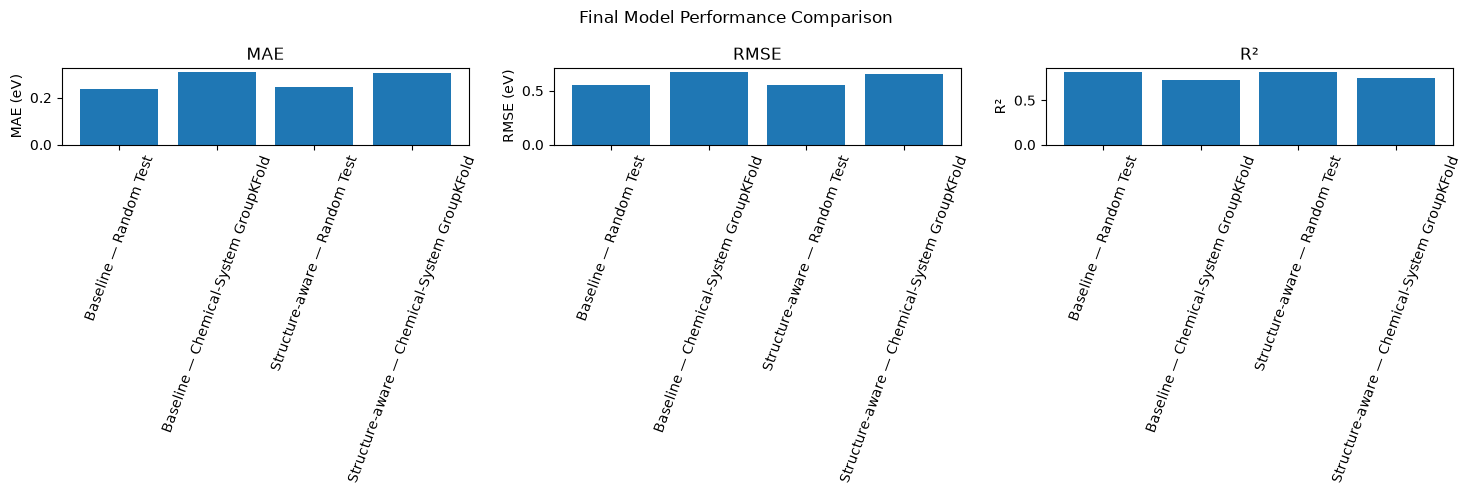

In [14]:
# ============================================================
# PERFORMANCE VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

metrics = [
    ("MAE (eV)", "MAE"),
    ("RMSE (eV)", "RMSE"),
    ("R²", "R²"),
]

for ax, (column, title) in zip(axes, metrics):

    ax.bar(
        results["Experiment"],
        results[column]
    )

    ax.set_title(title)
    ax.set_ylabel(column)

    ax.tick_params(
        axis="x",
        rotation=70
    )

plt.suptitle(
    "Final Model Performance Comparison"
)

plt.tight_layout()

plt.savefig(
    FIGURES / "final_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# ============================================================
# STRUCTURAL DESCRIPTOR ANALYSIS
# ============================================================

structural_comparison = pd.DataFrame({
    "Metric": [
        "MAE (eV)",
        "RMSE (eV)",
        "R²",
    ],

    "Baseline — 25 descriptors": [
        0.3109,
        0.6773,
        0.7324,
    ],

    "Structure-aware — 35 descriptors": [
        0.3044,
        0.6511,
        0.7524,
    ],
})

display(structural_comparison)

print("\nChanges under chemical-system GroupKFold:")
print("MAE  : -2.10%")
print("RMSE : -3.86%")
print("R²   : +0.0200")

structural_comparison.to_csv(
    RESULTS / "structural_model_comparison.csv",
    index=False
)

,Metric,Baseline — 25 descriptors,Structure-aware — 35 descriptors
0,MAE (eV),0.3109,0.3044
1,RMSE (eV),0.6773,0.6511
2,R²,0.7324,0.7524



Changes under chemical-system GroupKFold:
MAE  : -2.10%
RMSE : -3.86%
R²   : +0.0200


In [16]:
# ============================================================
# TRUSTWORTHINESS RESULTS
# ============================================================

trustworthiness = pd.DataFrame({
    "Analysis": [
        "Conformal nominal coverage",
        "Observed conformal coverage",
        "Conformal interval half-width",
        "Uncertainty Q1 MAE",
        "Uncertainty Q2 MAE",
        "Uncertainty Q3 MAE",
        "Uncertainty Q4 MAE",
    ],

    "Value": [
        "90.0%",
        "89.92%",
        "0.7849 eV",
        "0.000260 eV",
        "0.014709 eV",
        "0.170010 eV",
        "0.767611 eV",
    ],
})

display(trustworthiness)

uncertainty_error = pd.DataFrame({
    "Quartile": ["Q1", "Q2", "Q3", "Q4"],
    "Mean uncertainty": [
        0.000000,
        0.022369,
        0.319009,
        1.110804,
    ],
    "MAE": [
        0.000260,
        0.014709,
        0.170010,
        0.767611,
    ],
})

display(uncertainty_error)

,Analysis,Value
0,Conformal nominal coverage,90.0%
1,Observed conformal coverage,89.92%
2,Conformal interval half-width,0.7849 eV
3,Uncertainty Q1 MAE,0.000260 eV
4,Uncertainty Q2 MAE,0.014709 eV
5,Uncertainty Q3 MAE,0.170010 eV
6,Uncertainty Q4 MAE,0.767611 eV


,Quartile,Mean uncertainty,MAE
0,Q1,0.000000,0.000260
1,Q2,0.022369,0.014709
2,Q3,0.319009,0.170010
3,Q4,1.110804,0.767611


In [17]:
# ============================================================
# RETROSPECTIVE CANDIDATE SCREENING
# ============================================================

screening = {
    "Target band gap": "1.50 eV",
    "Maximum predicted distance": "0.10 eV",
    "Maximum uncertainty proxy": "0.40 eV",
    "Matching materials": 436,
    "Closest predicted band gap": "1.600 eV",
    "Closest material": "K2B2Se7",
    "Lowest uncertainty proxy": "0.009 eV",
}

screening_df = pd.DataFrame({
    "Screening quantity": screening.keys(),
    "Value": screening.values(),
})

display(screening_df)

print(
    "\nImportant: these are known JARVIS-DFT materials being "
    "retrospectively prioritized."
)
print(
    "This screening does not represent experimental discovery "
    "of previously unknown materials."
)

,Screening quantity,Value
0,Target band gap,1.50 eV
1,Maximum predicted distance,0.10 eV
2,Maximum uncertainty proxy,0.40 eV
3,Matching materials,436
4,Closest predicted band gap,1.600 eV
5,Closest material,K2B2Se7
6,Lowest uncertainty proxy,0.009 eV



Important: these are known JARVIS-DFT materials being retrospectively prioritized.
This screening does not represent experimental discovery of previously unknown materials.


In [18]:
# ============================================================
# FINAL RESEARCH SUMMARY JSON
# ============================================================

final_summary = {
    "project": "Machine-Learning-Assisted Discovery of Quantum Materials",

    "dataset": {
        "name": "JARVIS-DFT 3D",
        "materials": 93902,
        "target": "optb88vdw_bandgap",
        "units": "eV",
    },

    "baseline_model": {
        "model": "Random Forest Regressor",
        "trees": 200,
        "features": 25,
        "random_test_MAE_eV": 0.238135,
        "random_test_RMSE_eV": 0.555889,
        "random_test_R2": 0.819530,
        "groupkfold_MAE_eV": 0.3109,
        "groupkfold_RMSE_eV": 0.6773,
        "groupkfold_R2": 0.7324,
    },

    "structure_aware_model": {
        "features": 35,
        "groupkfold_MAE_eV": 0.3044,
        "groupkfold_RMSE_eV": 0.6511,
        "groupkfold_R2": 0.7524,
        "MAE_change_percent": -2.10,
        "RMSE_change_percent": -3.86,
        "R2_absolute_change": 0.0200,
    },

    "trustworthiness": {
        "conformal_nominal_coverage": 0.90,
        "conformal_observed_coverage": 0.8992,
        "conformal_interval_half_width_eV": 0.7849,
        "random_forest_uncertainty_is_calibrated": False,
    },

    "screening": {
        "target_bandgap_eV": 1.5,
        "maximum_distance_eV": 0.10,
        "maximum_uncertainty_eV": 0.40,
        "matching_materials": 436,
        "closest_material": "K2B2Se7",
        "closest_predicted_bandgap_eV": 1.600,
    },

    "conclusions": [
        "The Random Forest learns useful relationships between engineered descriptors and the JARVIS-DFT band gap.",
        "Random-split performance is higher than chemical-system GroupKFold performance.",
        "Chemical-system GroupKFold provides a stricter test of chemical generalization.",
        "Adding structural descriptors improves the chemical-system GroupKFold results.",
        "Conformal prediction provides a separate statistical calibration assessment.",
        "Random Forest tree dispersion is useful as a screening signal but is not a calibrated prediction interval.",
        "Candidate screening is retrospective prioritization of known database materials.",
    ],
}

summary_path = RESULTS / "final_research_summary.json"

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_summary,
        f,
        indent=4
    )

print("Saved:")
print(summary_path)

Saved:
F:\Quantum-materials\results\final_research_summary.json


# Final Research Conclusion

The completed workflow demonstrates that machine learning can learn useful
relationships between chemically and structurally informed descriptors and
JARVIS-DFT OptB88vdW band gaps.

The tuned Random Forest achieved:

- **MAE = 0.2381 eV**
- **RMSE = 0.5559 eV**
- **R² = 0.8195**

on the random test split.

Under the stricter chemical-system GroupKFold evaluation:

- **MAE = 0.3109 ± 0.0113 eV**
- **RMSE = 0.6773 ± 0.0380 eV**
- **R² = 0.7324 ± 0.0156**

Adding ten crystal-structure descriptors improved the chemical-system GroupKFold
results to:

- **MAE = 0.3044 ± 0.0108 eV**
- **RMSE = 0.6511 ± 0.0338 eV**
- **R² = 0.7524 ± 0.0170**

This provides evidence that structural information improves predictive
generalization in this experiment.

The project additionally incorporates:

- materials-aware validation,
- hyperparameter tuning,
- SHAP interpretation,
- permutation importance,
- conformal prediction,
- applicability-domain analysis,
- error analysis,
- uncertainty-aware candidate screening.

The screening workflow can prioritize existing JARVIS-DFT materials near a
desired band gap, but it should be described as **retrospective candidate
prioritization rather than experimental discovery**.

## Main limitation

The model predicts a DFT-derived band gap rather than an experimentally
measured property. Further validation using higher-level calculations,
experimental datasets, stability information, and eventually experimental
measurements would be required for materials-discovery applications.

## Final research statement

**Machine learning provides a useful computational framework for band-gap
prediction and candidate prioritization, while materials-aware validation,
structural information, and uncertainty analysis are essential for assessing
how reliably the model can generalize beyond chemically similar training
materials.**